opt test - WS20

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS20.csv" # Updated to your new dataset name
RANDOM_SEED  = 42

# Class Mapping and Imbalance Weights
CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]
# Heavily weight minority classes (BH and DB) vs majority (NB)
CLASS_WEIGHTS = {0: 1, 1: 20, 2: 20} 

# ─────────────────────────────────────────────────────────────────────────────
# ❷  FEATURE DEFINITIONS (Optimized for WS20 3-Class)
# ─────────────────────────────────────────────────────────────────────────────

G_LIST = [
    # --- Primary BH Detectors ---
    "pNN50_Ratio",             # RF Rank #3 (Excellent VIF: 1.04)
    "pNN50_Delta",             # RF Rank #4 (Excellent VIF: 1.80)
    "HF_Ratio",                # RF Rank #5 (Highly sig for BH)
    
    # --- Secondary HRV / Autonomic Nervous System features ---
    "RMSSD_Ratio",             # RF Rank #8 (Replaces the highly correlated SDNN/CV_RR)
    "Mean_RR_Ratio",           # RF Rank #13 (Captures overall heart rate baseline shifts)
    "Shannon_Entropy_Ratio",   # RF Rank #14 (Low VIF, mathematically orthogonal to others)

    # --- DB Isolators (Prevents DB from being classified as BH) ---
    "EDR_Std_Amp_Ratio",       # RF Rank #1 (The absolute best DB separator)
    "EDR_Mean_Amp_Delta"       # RF Rank #9 (Low VIF: 4.77, helps confirm DB isolation)
]

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION (Leave-One-Subject-Out)
# ═══════════════════════════════════════════════════════════════════════════════

def run_loso(df):
    """
    Leave-One-Subject-Out cross-validation for Multi-Class (NB, BH, DB).
    """
    print("\n" + "=" * 90)
    print("LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)")
    print("=" * 90)

    # Encode categories into integers
    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Header for metrics
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight=CLASS_WEIGHTS,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Evaluate on Held-Out Subject ─────────────────────────────────
        X_eval = df.loc[te_mask, G_LIST].fillna(0).values
        y_eval = df.loc[te_mask, "y"].values

        if len(y_eval) == 0:
            continue

        # predict_proba returns shape (N, 3) for the 3 classes
        eval_prob = clf.predict_proba(X_eval)
        # Select the class with the highest probability
        eval_pred = np.argmax(eval_prob, axis=1)

        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # Subject-level metrics (Macro average for multi-class)
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Results ───────────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found across subjects.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # ── ONE HOT ENCODING FOR METRICS ──
    # AUROC & AUPRC require the true labels to be One-Hot Encoded in multi-class
    yt_ohe = label_binarize(yt, classes=CLASSES)

    # Calculate overall metrics using macro-averaging
    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    # Use weights for AUPRC to account for class imbalance
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    
    cm = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── CALIBRATED LOSO OVERALL (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    np.random.seed(RANDOM_SEED)

    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found. Please run your feature extraction script first.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all required features are present
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return
        
    if "Category" not in df.columns:
        print("\n[!] ERROR: 'Category' column missing from data.")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")
    print(f"  Subjects = {df['Subject'].nunique()}")

    # Run the evaluation
    run_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS20.csv ...

Dataset Overview: 28,090 total windows
  NB = 21,529
  BH = 3,505
  DB = 3,056
  Subjects = 41

LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  469 |   40 |   75 | 0.870 |    0.701 |   0.758 |  0.721
  S_11   |  497 |   90 |   72 | 0.909 |    0.845 |   0.828 |  0.833
  S_14   |  497 |   90 |   79 | 0.869 |    0.794 |   0.729 |  0.757
  S_15   |  512 |   90 |   71 | 0.948 |    0.920 |   0.908 |  0.906
  S_16   |  493 |   90 |   76 | 0.944 |    0.930 |   0.890 |  0.907
  S_18   |  487 |   76 |   80 | 0.840 |    0.576 |   0.575 |  0.571
  S_19   |  456 |   90 |   81 | 0.852 |    0.875 |   0.695 |  0.713
  S_20   |  492 |   65 |   72 | 0.871 |    0.778 |   0.659 |  0.705
  S_21   |  514 |   90 |   71 | 0.905 |    0.892 |   0.777 |  0.821
  S_22   |  513 |   90 |   66 | 0.868 |    0.815 |   0.735 |  0.735
  S_23   

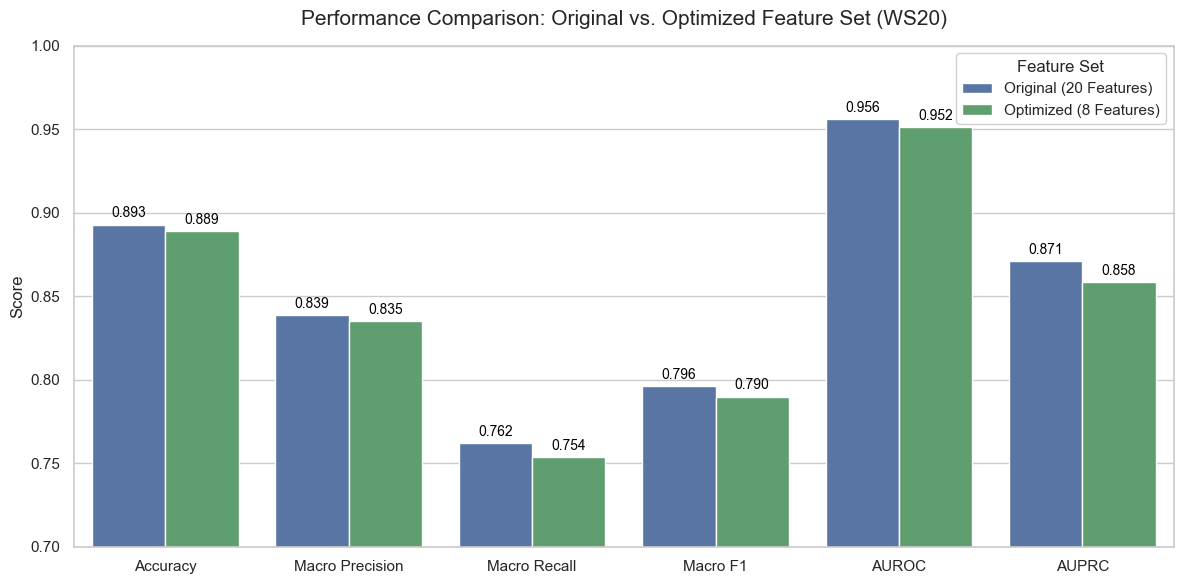

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_optimization_comparison():
    # Extracted data from your two WS20 runs
    data = {
        'Model': ['Original (20 Features)']*6 + ['Optimized (8 Features)']*6,
        'Metric': ['Accuracy', 'Macro Precision', 'Macro Recall', 'Macro F1', 'AUROC', 'AUPRC'] * 2,
        'Score': [
            0.893, 0.839, 0.762, 0.796, 0.9564, 0.8709, # Original 20 Features
            0.889, 0.835, 0.754, 0.790, 0.9516, 0.8584  # Optimized 8 Features
        ]
    }
    df = pd.DataFrame(data)

    # Set up styling
    sns.set_theme(style="whitegrid", palette="muted")
    colors = ['#4C72B0', '#55A868'] # Blue for Original, Green for Optimized

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df, x='Metric', y='Score', hue='Model', palette=colors)

    plt.title('Performance Comparison: Original vs. Optimized Feature Set (WS20)', fontsize=15, pad=15)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('')
    
    # Zoom Y-axis to clearly see the minimal drop
    plt.ylim(0.70, 1.0)

    # Add numeric labels on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    fontsize=10, color='black', xytext=(0, 8), 
                    textcoords='offset points')

    plt.legend(title='Feature Set', loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_optimization_comparison()

Opt Test - WS30

In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    recall_score, f1_score, accuracy_score,
    precision_score, confusion_matrix
)

# ─────────────────────────────────────────────────────────────────────────────
# ❶  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV    = "BH_DB_Features_WS30.csv" # Updated to your new dataset name
RANDOM_SEED  = 42

# Class Mapping and Imbalance Weights
CLASS_MAP    = {"NB": 0, "BH": 1, "DB": 2}
CLASSES      = [0, 1, 2]
# Heavily weight minority classes (BH and DB) vs majority (NB)
CLASS_WEIGHTS = {0: 1, 1: 20, 2: 20} 

# ─────────────────────────────────────────────────────────────────────────────
# ❷  FEATURE DEFINITIONS (Optimized for WS30 3-Class)
# ─────────────────────────────────────────────────────────────────────────────

G_LIST = [
    # --- Primary BH Detectors ---
    "HF_Ratio",                # RF Rank #2: Hugely powerful in WS30 (VIF: 4.2, p=0.000 for BH)
    "pNN50_Ratio",             # RF Rank #1: The ultimate global separator (VIF: 1.07)
    "pNN50_Delta",             # RF Rank #3: Strong secondary BH detector (VIF: 1.72)
    
    # --- Secondary HRV / Autonomic Nervous System features ---
    "Mean_RR_Ratio",           # RF Rank #11: Captures strict heart rate drops (p=0.0009 for BH)
    "RMSSD_Ratio",             # RF Rank #14: Replaces SDNN/CV_RR to fix severe VIF collinearity
    "Shannon_Entropy_Ratio",   # RF Rank #13: Low VIF (3.12), excellent mathematical diversity

    # --- DB Isolators (Filters out Deep Breathing false positives) ---
    "EDR_Std_Amp_Ratio",       # RF Rank #4: The absolute best respiration separator
    "EDR_Mean_Amp_Delta"       # RF Rank #6: Perfect secondary EDR feature (Low VIF: 4.86)
]

# ═══════════════════════════════════════════════════════════════════════════════
# LOSO EVALUATION (Leave-One-Subject-Out)
# ═══════════════════════════════════════════════════════════════════════════════

def run_loso(df):
    """
    Leave-One-Subject-Out cross-validation for Multi-Class (NB, BH, DB).
    """
    print("\n" + "=" * 90)
    print("LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)")
    print("=" * 90)

    # Encode categories into integers
    df["y"] = df["Category"].map(CLASS_MAP)
    subjects = sorted(df["Subject"].unique())

    all_y_true, all_y_prob, all_y_pred = [], [], []

    # Header for metrics
    header = (f"  {'Sub':6s} | {'N_NB':>4} | {'N_BH':>4} | {'N_DB':>4} | "
              f"{'Acc':>5} | {'Mac_Prec':>8} | {'Mac_Rec':>7} | {'Mac_F1':>6}")
    print(header)
    print("  " + "─" * (len(header) - 2))

    for test_sub in subjects:
        tr_mask = df["Subject"] != test_sub
        te_mask = df["Subject"] == test_sub

        # ── 1. Train on ALL OTHER Subjects ──────────────────────────────────
        X_tr = df.loc[tr_mask, G_LIST].fillna(0).values
        y_tr = df.loc[tr_mask, "y"].values

        base_rf = RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight=CLASS_WEIGHTS,
            random_state=RANDOM_SEED,
            n_jobs=-1
        )
        # Isotonic calibration applied to multi-class (One-vs-Rest internally)
        clf = CalibratedClassifierCV(base_rf, method="isotonic", cv=3)
        clf.fit(X_tr, y_tr)

        # ── 2. Evaluate on Held-Out Subject ─────────────────────────────────
        X_eval = df.loc[te_mask, G_LIST].fillna(0).values
        y_eval = df.loc[te_mask, "y"].values

        if len(y_eval) == 0:
            continue

        # predict_proba returns shape (N, 3) for the 3 classes
        eval_prob = clf.predict_proba(X_eval)
        # Select the class with the highest probability
        eval_pred = np.argmax(eval_prob, axis=1)

        all_y_true.extend(y_eval.tolist())
        all_y_prob.extend(eval_prob.tolist())
        all_y_pred.extend(eval_pred.tolist())

        # Subject-level metrics (Macro average for multi-class)
        acc  = accuracy_score(y_eval, eval_pred)
        prec = precision_score(y_eval, eval_pred, average='macro', zero_division=0)
        rec  = recall_score(y_eval, eval_pred, average='macro', zero_division=0)
        f1   = f1_score(y_eval, eval_pred, average='macro', zero_division=0)
        
        n_nb = (y_eval == 0).sum()
        n_bh = (y_eval == 1).sum()
        n_db = (y_eval == 2).sum()

        print(f"  {test_sub:6s} | {n_nb:>4} | {n_bh:>4} | {n_db:>4} | "
              f"{acc:>5.3f} | {prec:>8.3f} | {rec:>7.3f} | {f1:>6.3f}")

    # ── Aggregate Results ───────────────────────────────────────────────────
    if len(all_y_true) == 0:
        print("\n  [!] No valid evaluation windows found across subjects.")
        return

    yt = np.array(all_y_true)
    yp = np.array(all_y_prob)
    yd = np.array(all_y_pred)

    # ── ONE HOT ENCODING FOR METRICS ──
    # AUROC & AUPRC require the true labels to be One-Hot Encoded in multi-class
    yt_ohe = label_binarize(yt, classes=CLASSES)

    # Calculate overall metrics using macro-averaging
    auroc = roc_auc_score(yt_ohe, yp, multi_class='ovr', average='macro')
    # Use weights for AUPRC to account for class imbalance
    auprc = average_precision_score(yt_ohe, yp, average='macro')
    
    acc   = accuracy_score(yt, yd)
    prec  = precision_score(yt, yd, average='macro', zero_division=0)
    rec   = recall_score(yt, yd, average='macro', zero_division=0)
    f1    = f1_score(yt, yd, average='macro', zero_division=0)
    
    cm = confusion_matrix(yt, yd, labels=CLASSES)

    print("\n  " + "─" * 65)
    print(f"  ── CALIBRATED LOSO OVERALL (MACRO AVERAGED) ──")
    print(f"     AUROC (OVR) = {auroc:.4f}")
    print(f"     AUPRC       = {auprc:.4f}")
    print(f"     Accuracy    = {acc:.3f}")
    print(f"     Recall      = {rec:.3f}")
    print(f"     Precision   = {prec:.3f}")
    print(f"     F1 Score    = {f1:.3f}")
    
    print("\n     ── OVERALL CONFUSION MATRIX ──")
    print(f"                 Pred NB (0)   Pred BH (1)   Pred DB (2)")
    print(f"   Actual NB (0) {cm[0,0]:<13} {cm[0,1]:<13} {cm[0,2]:<13}")
    print(f"   Actual BH (1) {cm[1,0]:<13} {cm[1,1]:<13} {cm[1,2]:<13}")
    print(f"   Actual DB (2) {cm[2,0]:<13} {cm[2,1]:<13} {cm[2,2]:<13}")
    print("  " + "─" * 65)


# ═══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    np.random.seed(RANDOM_SEED)

    if not os.path.exists(INPUT_CSV):
        print(f"\n[!] ERROR: {INPUT_CSV} not found. Please run your feature extraction script first.")
        return

    print(f"Loading {INPUT_CSV} ...")
    df = pd.read_csv(INPUT_CSV)
    
    # Ensure all required features are present
    missing = [f for f in G_LIST if f not in df.columns]
    if missing:
        print(f"\n[!] ERROR: Missing features in CSV: {missing}")
        return
        
    if "Category" not in df.columns:
        print("\n[!] ERROR: 'Category' column missing from data.")
        return

    print(f"\nDataset Overview: {len(df):,} total windows")
    for cat in CLASS_MAP.keys():
        count = (df['Category'] == cat).sum()
        print(f"  {cat} = {count:,}")
    print(f"  Subjects = {df['Subject'].nunique()}")

    # Run the evaluation
    run_loso(df)

if __name__ == "__main__":
    main()

Loading BH_DB_Features_WS30.csv ...

Dataset Overview: 25,290 total windows
  NB = 18,116
  BH = 2,252
  DB = 4,922
  Subjects = 41

LOSO EVALUATION: MULTI-CLASS (NB, BH, DB)
  Sub    | N_NB | N_BH | N_DB |   Acc | Mac_Prec | Mac_Rec | Mac_F1
  ─────────────────────────────────────────────────────────────────
  S_10   |  389 |    0 |  115 | 0.863 |    0.585 |   0.542 |  0.563
  S_11   |  417 |   60 |  112 | 0.844 |    0.798 |   0.818 |  0.806
  S_14   |  407 |   60 |  129 | 0.836 |    0.836 |   0.759 |  0.792
  S_15   |  432 |   60 |  114 | 0.947 |    0.935 |   0.928 |  0.927
  S_16   |  403 |   60 |  126 | 0.907 |    0.935 |   0.867 |  0.890
  S_18   |  407 |   43 |  122 | 0.844 |    0.556 |   0.566 |  0.559
  S_19   |  372 |   60 |  129 | 0.836 |    0.906 |   0.644 |  0.693
  S_20   |  409 |   31 |  121 | 0.834 |    0.779 |   0.738 |  0.757
  S_21   |  434 |   60 |  111 | 0.881 |    0.907 |   0.765 |  0.820
  S_22   |  433 |   60 |  111 | 0.897 |    0.887 |   0.770 |  0.787
  S_23   

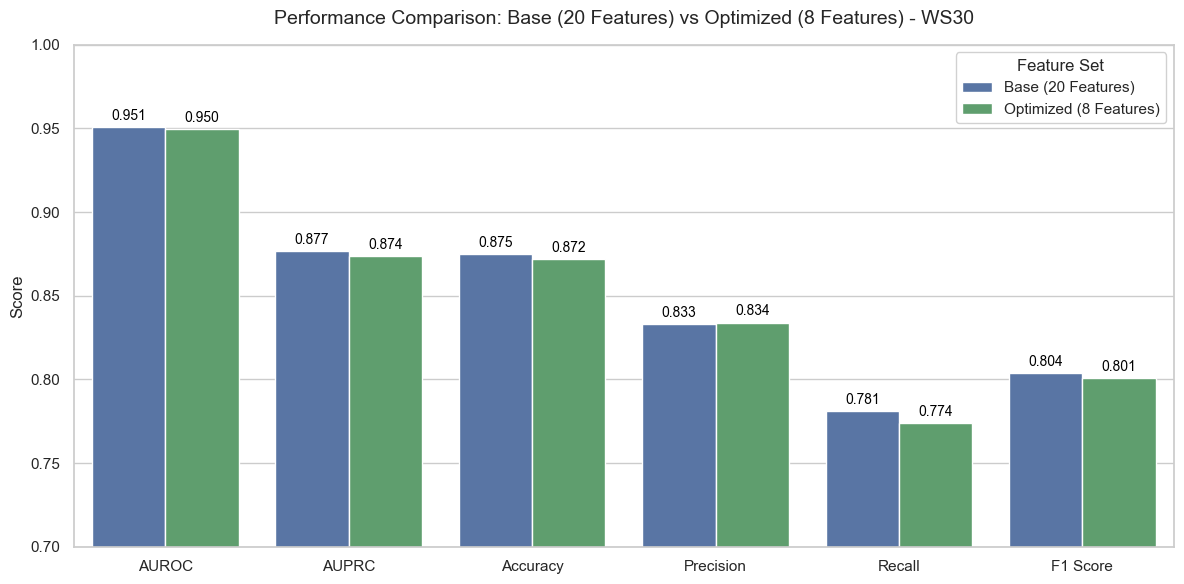

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_optimization_comparison_ws30():
    # Data extracted from the WS30 logs
    data = {
        'Metric': ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'Base (20 Features)': [0.9506, 0.8766, 0.875, 0.833, 0.781, 0.804],
        'Optimized (8 Features)': [0.9497, 0.8740, 0.872, 0.834, 0.774, 0.801]
    }

    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars='Metric', var_name='Model', value_name='Score')

    # Set plotting style
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")

    # Custom colors: Blue for Base, Green for Optimized
    colors = ['#4C72B0', '#55A868']

    ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette=colors)

    plt.title('Performance Comparison: Base (20 Features) vs Optimized (8 Features) - WS30', fontsize=14, pad=15)
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('')

    # Zoom in on the Y-axis to highlight the marginal differences
    plt.ylim(0.70, 1.0)

    # Add numerical labels above the bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    fontsize=10, color='black', xytext=(0, 8), 
                    textcoords='offset points')

    plt.legend(title='Feature Set', loc='upper right', framealpha=0.9)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_optimization_comparison_ws30()

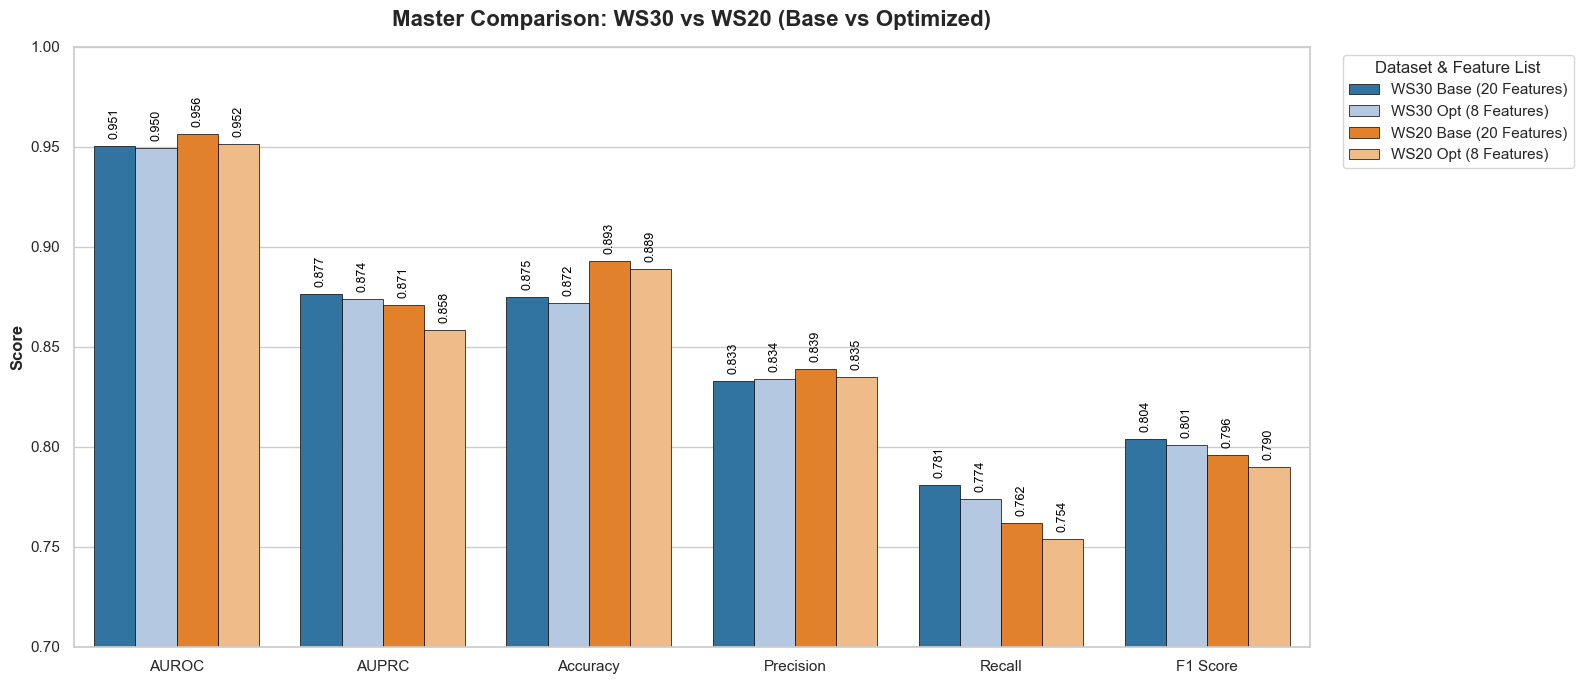

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_master_comparison():
    # Data extracted from all previous logs
    data = {
        'Metric': ['AUROC', 'AUPRC', 'Accuracy', 'Precision', 'Recall', 'F1 Score'],
        'WS30 Base (20 Features)': [0.9506, 0.8766, 0.875, 0.833, 0.781, 0.804],
        'WS30 Opt (8 Features)':   [0.9497, 0.8740, 0.872, 0.834, 0.774, 0.801],
        'WS20 Base (20 Features)': [0.9564, 0.8709, 0.893, 0.839, 0.762, 0.796],
        'WS20 Opt (8 Features)':   [0.9516, 0.8584, 0.889, 0.835, 0.754, 0.790]
    }

    df = pd.DataFrame(data)
    df_melted = df.melt(id_vars='Metric', var_name='Model', value_name='Score')

    # Set plotting style
    plt.figure(figsize=(16, 7))
    sns.set_theme(style="whitegrid")

    # Custom colors: Dark/Light Blue for WS30, Dark/Light Orange for WS20
    colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78']

    ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', 
                     palette=colors, edgecolor='black', linewidth=0.5)

    plt.title('Master Comparison: WS30 vs WS20 (Base vs Optimized)', fontsize=16, pad=15, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.xlabel('')

    # Zoom in on the Y-axis
    plt.ylim(0.70, 1.0)

    # Add numerical labels above the bars
    for p in ax.patches:
        # Prevent plotting labels for empty bars (if any)
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.3f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        fontsize=9, color='black', xytext=(0, 5), 
                        textcoords='offset points', rotation=90)

    # Put legend outside the plot so it doesn't cover data
    plt.legend(title='Dataset & Feature List', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_master_comparison()